<a href="https://colab.research.google.com/github/marioguerrerosalah/APRENDIZAJE-NO-SUPERVISADO/blob/main/DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DBSCAN**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cargue de librerías

In [ ]:
#!pip install scikit-learn-extra # No está instalado por defecto en Colab
import pandas as pd
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
#from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

## Cargue de los datos

In [ ]:
import pandas as pd
path= '/content/drive/MyDrive/APREN. NO SUPERVISADO/marketing_campaign1.csv'
df= pd.read_csv(path, sep="\t")

In [ ]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## Creación de variables requeridas

In [ ]:
df['Edad']= 2014 - df['Year_Birth'] #Creación de la variable de edad
var_gast= ['MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']
df['gast_per']= df[var_gast].sum(axis=1) #Creación de la variable del gasto total entre todas las categorias

In [ ]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Edad,gast_per
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,0,3,11,1,57,1617
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,0,3,11,0,60,27
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,0,3,11,0,49,776
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,0,3,11,0,30,53
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,0,3,11,0,33,422


## Limpieza de datos

In [ ]:
df= df.dropna() # Eliminación de registros con datos faltantes

## Creación del dataset para el clustering solicitado
Se requiere un dataset solo con las personas casadas *Married* que tengan hijos pequeños *Kidhome* viviendo en casa.

In [ ]:
dfn= df[(df['Marital_Status']== 'Married') & df['Kidhome']>0]


In [ ]:
dfn.head()
dfn.shape
dfn.describe()
dfn.info(9)

<class 'pandas.core.frame.DataFrame'>
Index: 349 entries, 4 to 2239
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   349 non-null    int64  
 1   Year_Birth           349 non-null    int64  
 2   Education            349 non-null    object 
 3   Marital_Status       349 non-null    object 
 4   Income               349 non-null    float64
 5   Kidhome              349 non-null    int64  
 6   Teenhome             349 non-null    int64  
 7   Dt_Customer          349 non-null    object 
 8   Recency              349 non-null    int64  
 9   MntWines             349 non-null    int64  
 10  MntFruits            349 non-null    int64  
 11  MntMeatProducts      349 non-null    int64  
 12  MntFishProducts      349 non-null    int64  
 13  MntSweetProducts     349 non-null    int64  
 14  MntGoldProds         349 non-null    int64  
 15  NumDealsPurchases    349 non-null    int64  

In [ ]:
dfn = dfn.drop('ID', axis=1)

## Exploración visual de los datos

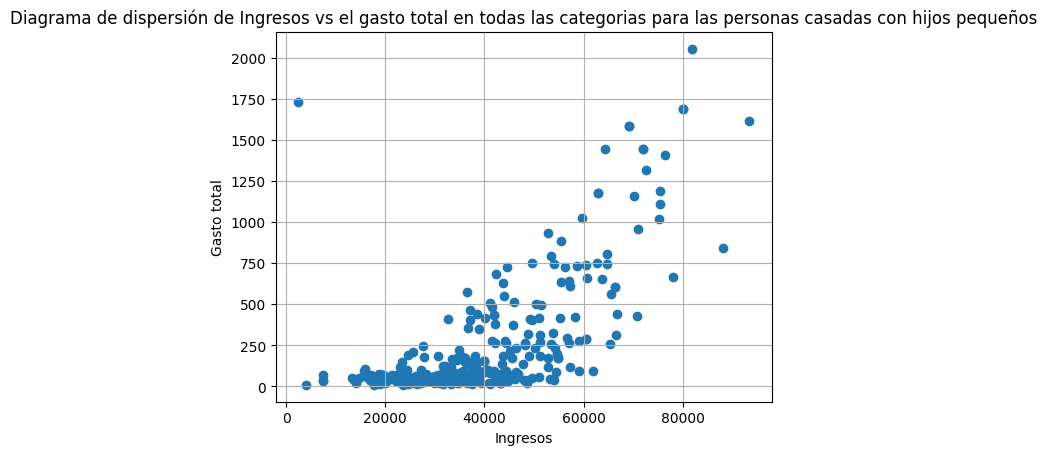

In [ ]:
plt.scatter(dfn['Income'], dfn['gast_per'])
plt.title('Diagrama de dispersión de Ingresos vs el gasto total en todas las categorias para las personas casadas con hijos pequeños')
plt.xlabel('Ingresos')
plt.ylabel('Gasto total')
plt.grid(True)

## Estandarización de los datos para clustering

In [ ]:
data= dfn.loc[:, ['Income','gast_per']] # Se seleccionan solo las dos columnas con las que se va a trabajar
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data)

## Creación del modelo de clustering con DBSCAN
Se deben seleccionar el Epsilon, que corresponde a la distancia entre los puntos y el número mínimo de puntos para que un punto haga parte del cluster.

In [ ]:
db = DBSCAN(eps=0.5, min_samples=5).fit(scaled_features)


## Cargue de las etiquetas en el dataframe con todas las variables

In [ ]:
dfn.loc[:, 'dbscan_labels'] = db.labels_

In [ ]:
dfn

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Edad,gast_per,dbscan_labels
4,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,...,0,0,0,0,3,11,0,33,422,0
7,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,10,...,0,0,0,0,3,11,0,29,169,0
16,1980,Graduation,Married,41850.0,1,1,24-12-2012,51,53,5,...,0,0,0,0,3,11,0,34,96,0
21,1979,Graduation,Married,2447.0,1,0,06-01-2013,42,1,1,...,0,0,0,0,3,11,0,35,1730,-1
26,1976,Graduation,Married,53359.0,1,1,27-05-2013,4,173,4,...,0,0,0,0,3,11,0,38,257,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2199,1975,Graduation,Married,37085.0,1,1,26-06-2014,65,39,1,...,0,0,0,0,3,11,0,39,61,0
2223,1963,Master,Married,33562.0,1,2,25-06-2014,33,21,12,...,0,0,0,0,3,11,0,51,51,0
2226,1979,Graduation,Married,63777.0,1,1,24-03-2013,87,457,5,...,0,0,0,0,3,11,0,35,653,0
2234,1974,Graduation,Married,34421.0,1,0,01-07-2013,81,3,3,...,0,0,0,0,3,11,0,40,30,0


In [ ]:
dfn['dbscan_labels'].value_counts()

,count
dbscan_labels,
0,328
1,13
-1,8


## Interpretación en DBSCAN

    Clusters densos y bien separados:
        Si DBSCAN encuentra buenos clusters, el coeficiente de silueta será alto (>0.5), indicando que los puntos están bien agrupados.

    Clusters con ruido o mal definidos:
        Muchos puntos con S(i)≈ 0 o negativos pueden indicar que ε o minPts no son adecuados.
        
        Si ε es muy grande, los clusters pueden estar fusionados, reduciendo la calidad del clustering.

        Si ε es muy pequeño, DBSCAN puede marcar muchos puntos como ruido, disminuyendo el coeficiente de silueta.

    Ruido (-1 en DBSCAN):
        Los puntos marcados como ruido no tienen cluster asignado, por lo que en la implementación estándar de sklearn.metrics.silhouette_score(), estos puntos suelen ser ignorados en el cálculo.
       

## Evaluación del modelo
Coeficiente de la silueta *Silhouette Score*
Esta es una medida de cohesión, que indica que tan bien asignadas están las observaciones dentro del cluster respectivo.

In [ ]:
dbscan_labels = db.labels_
silhouette_avg = silhouette_score(scaled_features, dbscan_labels)
print("DBSCAN Silhouette Score:", silhouette_avg)

DBSCAN Silhouette Score: 0.6469545045735967


## ¿Cómo seleccionar los valores más apropiados para el modelo de `DBSCAN`?
Aunque el coeficiente de la silueta es un indicador del performance del modelo.
Probaremos con diferentes combinaciones para los valores de epsilon y del número mínimo de puntos para analizar el desempeño del modelo de DBSCAN con los valores respectivos.

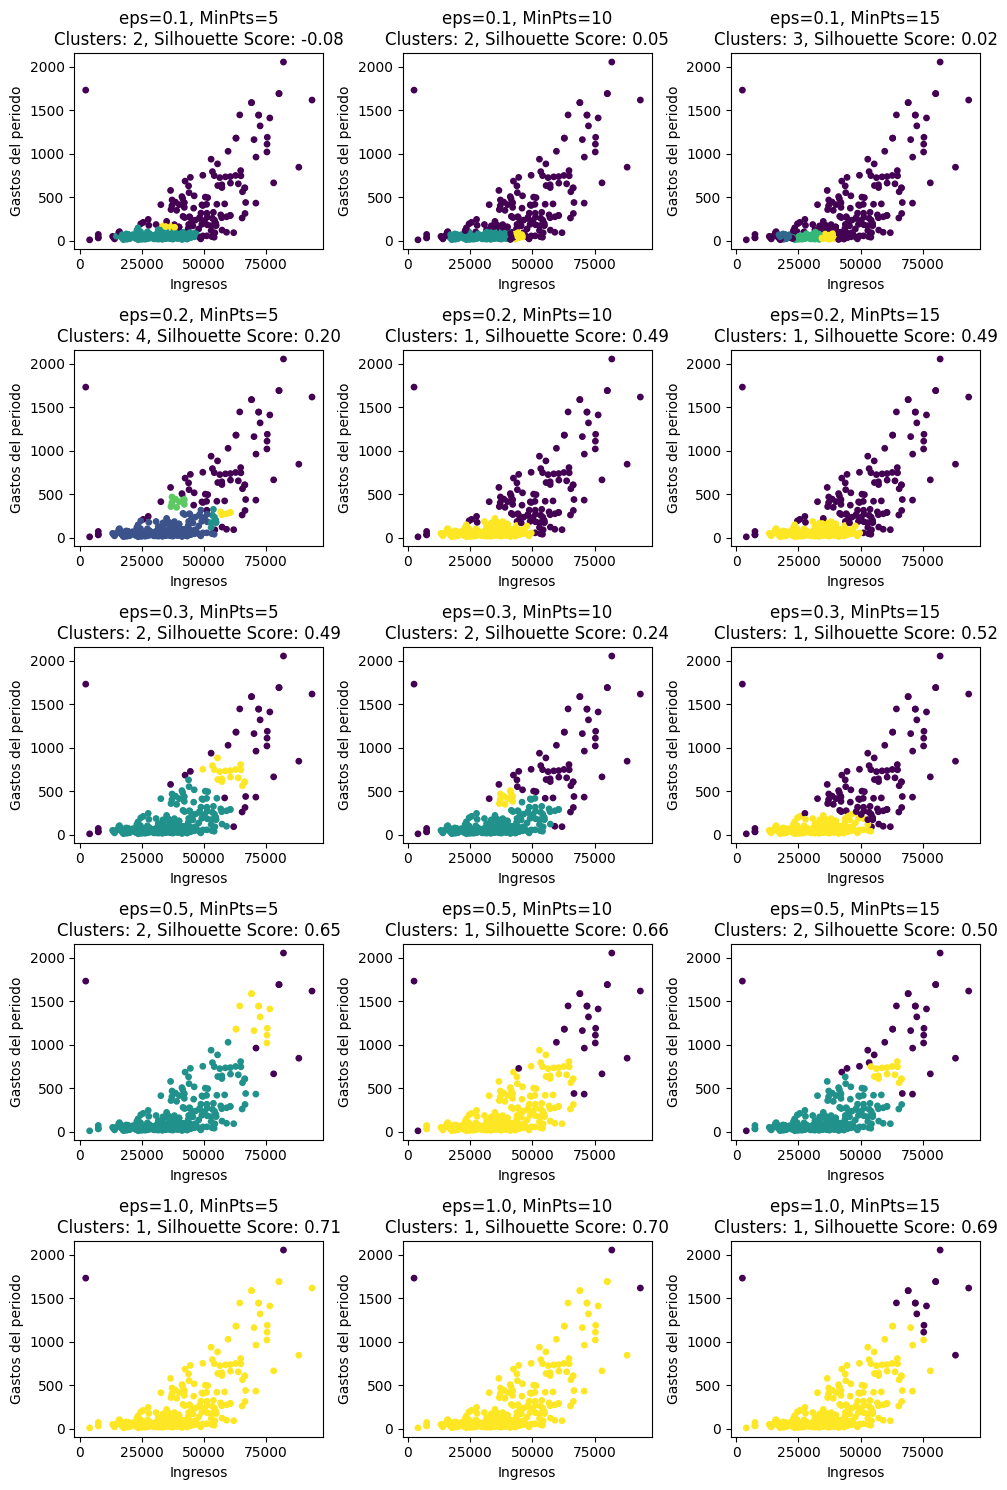

In [ ]:
eps_values = [0.1, 0.2, 0.3, 0.5, 1.0]
minPts_values = [5, 10, 15]

results = []
fig, axs = plt.subplots(len(eps_values), len(minPts_values), figsize=(10, 15))

for i, minPts in enumerate(minPts_values):
    for j, eps in enumerate(eps_values):

        dbscan_model = DBSCAN(eps=eps, min_samples=minPts)
        dbscan_labels = dbscan_model.fit_predict(scaled_features)


        silhouette_avg = silhouette_score(scaled_features, dbscan_labels)

        unique_labels = set(dbscan_model.labels_)
        unique_labels.discard(-1)
        num_clusters = len(unique_labels)


        axs[j, i].scatter(data['Income'], data['gast_per'], c=dbscan_labels, s=15)
        axs[j, i].set_title(f'eps={eps}, MinPts={minPts}\nClusters: {num_clusters}, Silhouette Score: {silhouette_avg:.2f}')
        axs[j, i].set_ylabel('Gastos del periodo')
        axs[j, i].set_xlabel('Ingresos')


        results.append({
            'Epsilon (eps)': eps,
            'MinPts': minPts,
            'Silhouette Score': silhouette_avg,
            'Numero de clusters': num_clusters
        })

plt.tight_layout()
plt.show()

Como podemos observar, tenemos modelos con un coeficiente de la silueta muy alto, pero solo nos están generando un solo cluster, por lo tanto, no tienen  mucho sentido utilizarlos.

In [ ]:
results_df= pd.DataFrame(results)
results_df

,Epsilon (eps),MinPts,Silhouette Score,Numero de clusters
0,0.1,5,-0.081653,2
1,0.2,5,0.203546,4
2,0.3,5,0.491115,2
3,0.5,5,0.646955,2
4,1.0,5,0.708748,1
5,0.1,10,0.047846,2
6,0.2,10,0.490807,1
7,0.3,10,0.236973,2
8,0.5,10,0.663079,1
9,1.0,10,0.703001,1


Text(0.5, 1.0, 'Desempeño de los modelos según el coeficiente de la silueta')

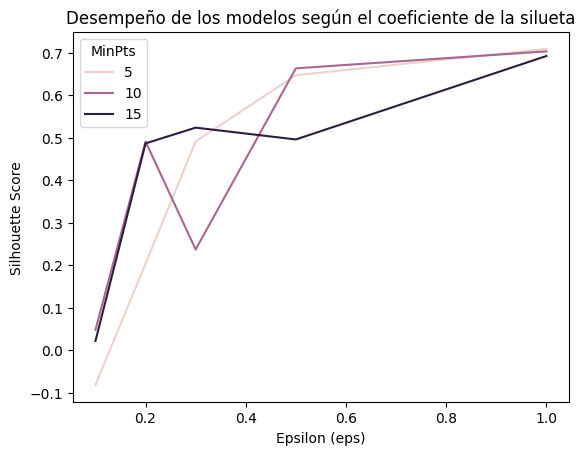

In [ ]:
sns.lineplot(x=results_df['Epsilon (eps)'], y=results_df['Silhouette Score'], hue=results_df['MinPts'])
plt.title('Desempeño de los modelos según el coeficiente de la silueta')

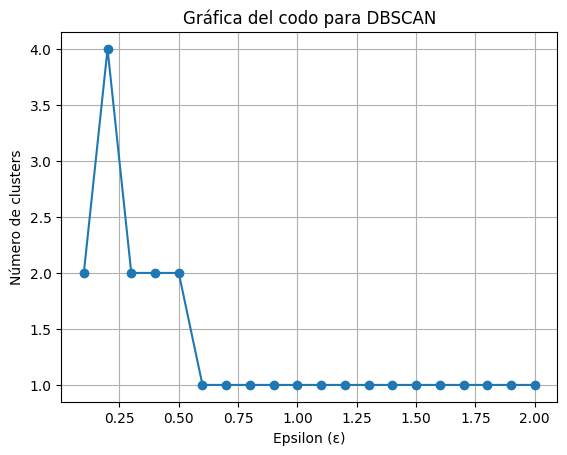

In [ ]:
epsilon_values = np.linspace(0.1, 2.0, 20)


num_clusters = []


for epsilon in epsilon_values:
    dbscan_model = DBSCAN(eps=epsilon)
    dbscan_labels = dbscan_model.fit_predict(scaled_features)


    num_clusters.append(len(np.unique(dbscan_labels)) - 1)


plt.plot(epsilon_values, num_clusters, marker='o')
plt.xlabel('Epsilon (ε)')
plt.ylabel('Número de clusters')
plt.title('Gráfica del codo para DBSCAN')
plt.grid(True)
plt.show()

Actualizamos el modelo con los hiperparametros seleccionados y actualizamos las etiquetas del clustering en el dataset con todas las variables.

In [ ]:
db = DBSCAN(eps=0.3, min_samples=5).fit(scaled_features)
dfn.loc[:, 'dbscan_labels'] = db.labels_

Text(0.5, 1.0, 'Diagrama de dispersión para DBSCAN')

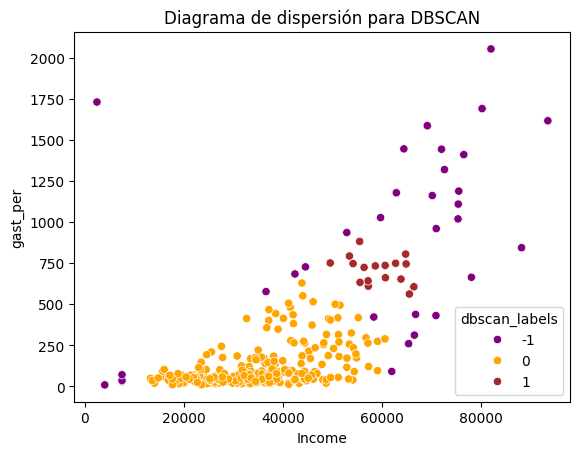

In [ ]:
custom_palette = {-1:'purple', 0:'orange', 1:'brown'}
sns.scatterplot(data=dfn,x='Income',y='gast_per', hue='dbscan_labels', palette=custom_palette)
plt.title('Diagrama de dispersión para DBSCAN')

## Correlación por clúster entre las variables (Ingresos y gastos total)

In [ ]:
dfn.groupby('dbscan_labels')[['Income','gast_per']].corr()

Income  gast_per
dbscan_labels                             
-1            Income    1.000000  0.532987
              gast_per  0.532987  1.000000
 0            Income    1.000000  0.461512
              gast_per  0.461512  1.000000
 1            Income    1.000000 -0.404677
              gast_per -0.404677  1.000000

## Exploración de los clústers por las otras variables disponibles

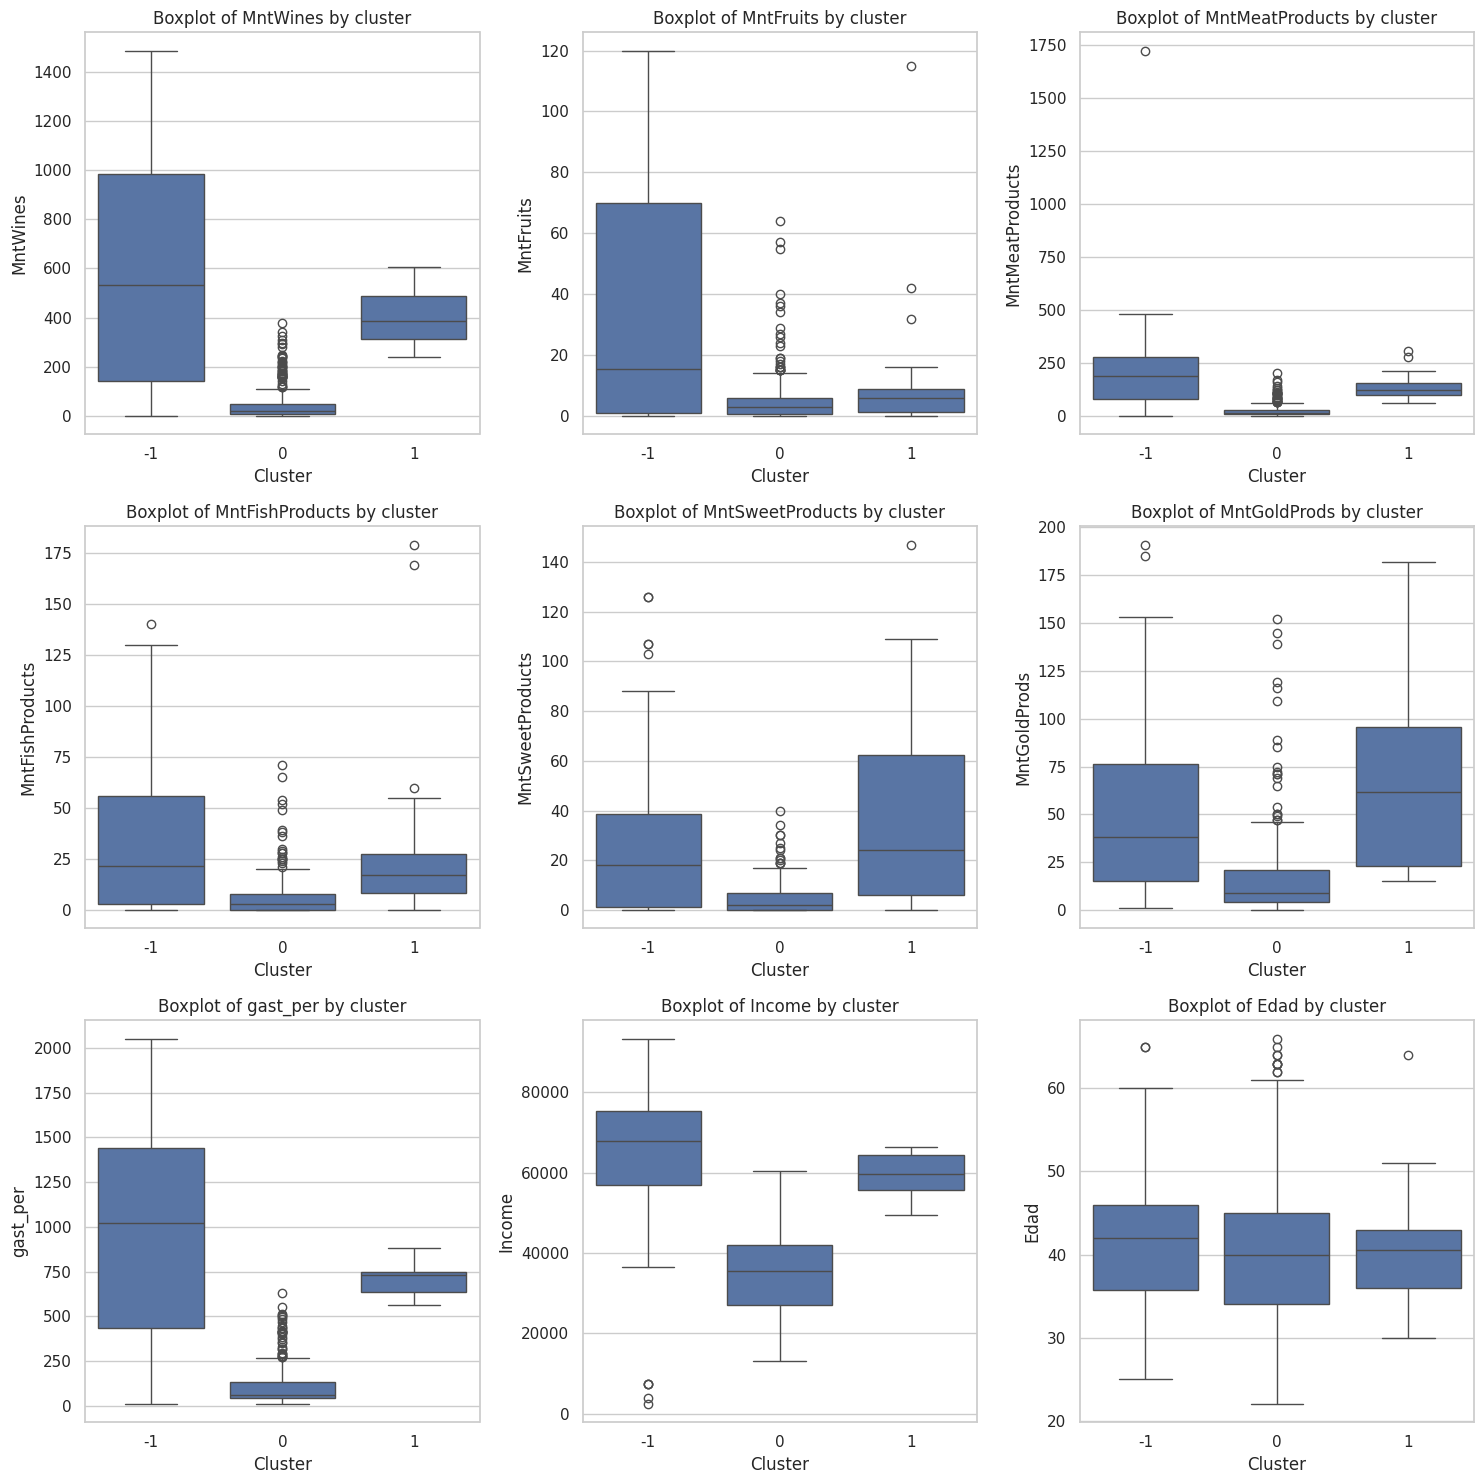

In [ ]:
import math
columns_to_keep = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'gast_per', 'Income', 'Edad', 'dbscan_labels']
dfn2 = dfn.loc[:, columns_to_keep]


num_columns = min(len(columns_to_keep), 9)
num_rows = math.ceil(num_columns / 3)


sns.set(style="whitegrid")


fig, axes = plt.subplots(nrows=num_rows, ncols=3, figsize=(15, 5*num_rows))


for i, column in enumerate(columns_to_keep[:9]):
    row = i // 3
    col = i % 3
    sns.boxplot(x='dbscan_labels', y=column, data=dfn2, ax=axes[row, col])
    axes[row, col].set_title(f'Boxplot of {column} by cluster')
    axes[row, col].set_xlabel('Cluster')
    axes[row, col].set_ylabel(column)


for i in range(num_columns, num_rows*3):
    row = i // 3
    col = i % 3
    fig.delaxes(axes[row, col])


plt.tight_layout()
plt.show()

#**KMEANS**

In [ ]:
kmeans = KMeans(
  init="random",
  n_clusters=3,
  n_init=10,
  max_iter=300,
  random_state=42
  )

In [ ]:
kmeans.fit(scaled_features)

In [ ]:
kmeans.inertia_

In [ ]:
kmeans.cluster_centers_

In [ ]:
kmeans_labels = kmeans.predict(scaled_features)


In [ ]:
standardized_centroids = kmeans.cluster_centers_

original_centroids = scaler.inverse_transform(standardized_centroids)
original_centroids

In [ ]:
dfn['kmeans_labels']= kmeans_labels
dfn

## Visualización de kmeans

In [ ]:
x_col = dfn['Income']
y_col = dfn['gast_per']

cluster_colors = {0: 'orange', 1: 'green', 2: 'brown'}
scatter_colors = [cluster_colors[label] for label in dfn['kmeans_labels']]

plt.scatter( x_col,y_col, c=scatter_colors, s=15)

standardized_centroids = kmeans.cluster_centers_
centroids = scaler.inverse_transform(standardized_centroids)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="x",
    s=50,
    linewidths=3,
    color="blue",
    zorder=10,
)
plt.title('Diagrama de dispersión Clusters creados con Ingresos vs gastos periodo - Kmeans')
plt.ylabel('Gastos del periodo')
plt.xlabel('Ingresos')

In [ ]:
silhouette_avg = silhouette_score(scaled_features, kmeans_labels)
print("Kmeans Silhouette Score:", silhouette_avg)

#Kmedoids

In [ ]:

n_clusters = 3

kmedoids = KMedoids(n_clusters=n_clusters, random_state=0).fit(scaled_features)

centroids = kmedoids.cluster_centers_
labels = kmedoids.labels_

print("Cluster centroids:", centroids)


In [ ]:
standardized_centroids = kmedoids.cluster_centers_

original_centroids = scaler.inverse_transform(standardized_centroids)
original_centroids

In [ ]:
dfn['kmedoids_labels']= labels

In [ ]:
x_col = dfn['Income']
y_col = dfn['gast_per']

cluster_colors = {0: 'orange', 1: 'green', 2: 'brown'}
scatter_colors = [cluster_colors[label] for label in dfn['kmedoids_labels']]

plt.scatter( x_col,y_col, c=scatter_colors, s=15)

standardized_centroids = kmedoids.cluster_centers_
centroids = scaler.inverse_transform(standardized_centroids)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="x",
    s=50,
    linewidths=3,
    color="blue",
    zorder=10,
)
plt.title('Diagrama de dispersión Clusters creados con Ingresos vs gastos periodo - Kmedoids')
plt.ylabel('Gastos del periodo')
plt.xlabel('Ingresos')

# Detección de outliers

In [ ]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest(random_state=42)
clf.fit(data)

# Predicción de outliers
y_pred = clf.predict(data)

# Número de outliers
n_outliers = (y_pred == -1).sum()
print("\nNumber of outliers detected:", n_outliers)

Se cargan las etiquetas de los outliers en el dataset

In [ ]:
dfn['outliers']= y_pred

##`Tarea:`

1.   Visualizar los outliers en un gráfico de dispersión
2.   Correr los algoritmos de clustering sin los outliers y analizar los resultados.
